# Assignment: Text Generation with RNNs

In this assignment, you will explore text generation using deep learning models, specifically Recurrent Neural Networks (RNNs). Text generation is a fascinating task where the goal is to train a model that can predict the next word in a sequence, ultimately generating coherent and contextually accurate sentences or paragraphs.

You will work with a corpus of text data provided in the tutorial (from TensorFlow), which contains a large collection of Shakespeare’s works. Your objective is to implement a text generation model using RNNs and to evaluate its performance based on various metrics.

<img src="https://drek4537l1klr.cloudfront.net/teofili2/Figures/03fig09_alt.jpg" alt="Drawing"/>

**The models include:**
- Deep RNN (LSTM)
- Deep RNN (GRU)
- Bidirectional RNN


**Evaluation:**

Evaluate the performance of the text generation model using several metrics:
- Perplexity: A measure of how well the probability distribution predicted by the model aligns with the actual distribution of words in the text.
- Generated Text Quality: Subjectively evaluate the quality of the generated text by considering grammar, coherence, and creativity. This can be done by visually inspecting the generated sequences.
- BLUE Score: Character-level BLEU: BLEU can be applied at the character level by treating each character as an n-gram. This is particularly useful when the task involves generating character sequences (like poetry, code, or fine-grained character-based generation).
For example, the sequence “hello” could be evaluated by comparing 1-grams (e.g., “h”, “e”, “l”, “l”, “o”) or higher-order n-grams (e.g., “he”, “el”, “ll”, “lo”).

**Goals:**

- Compare the performance of GRU and LSTM. Is there a significant difference in the results?
- Compare the performance of the unidirectional and bidirectional RNN models.
Which model produces better results?
- Discuss the impact of bidirectional RNNs on text generation tasks.

# Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import numpy as np
import nltk
from nltk.translate.bleu_score import sentence_bleu
import os
import time

# Dataset

The Shakespeare dataset used for text generation contains a collection of works by William Shakespeare, primarily in the form of plays and sonnets. The text is used to train language models, offering an ideal example for character-level modeling due to its rich, complex language. The dataset is often preprocessed by tokenizing it into individual characters, enabling models to learn the sequential relationships between characters for generating coherent and contextually appropriate text.

To access the dataset, you can use TensorFlow's get_file method as follow:

You can inspect the dataset on [Kaggle](https://www.kaggle.com/datasets/adarshpathak/shakespeare-text/data).

In [2]:
path_to_file = 'shakespeare.txt'

text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
# length of text is the number of characters in it
print(f'Length of text: {len(text)} characters')

Length of text: 1115393 characters


In [3]:
# first 250 characters in text
print(text[:250])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



# Process the text

### Vectorize the text

Before training, you need to convert the strings to a numerical representation.

The `tf.keras.layers.StringLookup` layer can convert each character into a numeric ID. It just needs the text to be split into tokens first.

In [4]:
example_texts = ['abcdefg', 'xyz']

chars = tf.strings.unicode_split(example_texts, input_encoding='UTF-8')
chars

<tf.RaggedTensor [[b'a', b'b', b'c', b'd', b'e', b'f', b'g'], [b'x', b'y', b'z']]>


Now create the [`tf.keras.layers.StringLookup`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/StringLookup) layer:

Since the goal of this assignment is to generate text, it will also be important to invert this representation and recover human-readable strings from it. For this you can use tf.keras.layers.StringLookup(..., invert=True).

Note: Here instead of passing the original vocabulary generated with sorted(set(text)) use the get_vocabulary() method of the tf.keras.layers.StringLookup layer so that the [UNK] tokens is set the same way.

In [5]:
def get_string_lookup_layers(vocab):
    """
    Creates StringLookup layers for encoding characters to IDs and decoding IDs back to characters.

    Args:
        vocab (list): List of unique characters in the dataset.

    Returns:
        ids_from_chars (tf.keras.layers.StringLookup): Converts characters to IDs.
        chars_from_ids (tf.keras.layers.StringLookup): Converts IDs back to characters.
    """
    ids_from_chars = tf.keras.layers.StringLookup(vocabulary=vocab, mask_token=None)

    chars_from_ids = tf.keras.layers.StringLookup(
        vocabulary=ids_from_chars.get_vocabulary(),
        invert=True,
        mask_token=None
    )
    return ids_from_chars, chars_from_ids

In [6]:
def text_from_ids(ids, chars_from_ids):
    """
    Converts a sequence of character IDs into a human-readable string.

    Args:
        ids (tf.Tensor): Tensor of character IDs.
        chars_from_ids (tf.keras.layers.StringLookup): StringLookup layer to decode IDs.

    Returns:
        tf.Tensor: Decoded string.
    """
    ids = tf.convert_to_tensor(ids)
    return tf.strings.reduce_join(chars_from_ids(ids), axis=-1)

# Create training examples and targets

Next divide the text into example sequences. Each input sequence will contain seq_length characters from the text.

For each input sequence, the corresponding targets contain the same length of text, except shifted one character to the right.

So break the text into chunks of seq_length+1. For example, say seq_length is 4 and our text is "Hello". The input sequence would be "Hell", and the target sequence "ello".

To do this first use the tf.data.Dataset.from_tensor_slices function to convert the text vector into a stream of character indices.

For training you'll need a dataset of (input, label) pairs. Where input and label are sequences. At each time step the input is the current character and the label is the next character.

Here's a function that takes a sequence as input, duplicates, and shifts it to align the input and label for each timestep:

In [7]:
def split_input_target(sequence):
    input_text = sequence[:-1]
    target_text = sequence[1:]
    return input_text, target_text

Convert Text to Numerical Sequences

In [8]:
# Initialize mapping layers
vocab = sorted(set(text))
ids_from_chars, chars_from_ids = get_string_lookup_layers(vocab)

# Convert text to character IDs
all_ids = ids_from_chars(tf.strings.unicode_split(text, 'UTF-8'))

# Create a dataset from the character IDs
ids_dataset = tf.data.Dataset.from_tensor_slices(all_ids)

Create Sequences for Training

In [10]:
seq_length = 100  # Length of each training sequence

# Batch sequences (each sequence is seq_length + 1)
sequences = ids_dataset.batch(seq_length + 1, drop_remainder=True)

# Map dataset to input-target format
dataset = sequences.map(split_input_target)

# Print sample input-output pairs
for input_example, target_example in dataset.take(1):
    print("Input :", tf.strings.reduce_join(chars_from_ids(input_example)).numpy().decode('utf-8'))
    print("Target:", tf.strings.reduce_join(chars_from_ids(target_example)).numpy().decode('utf-8'))

Input : First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
Target: irst Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You 


2025-11-11 18:17:06.063514: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Create RNN Models

Before training our text generation models, we need to set up key parameters and prepare the dataset. These parameters control the size of batches, buffer size for shuffling, embedding dimensions, and the number of units in the recurrent layer.

Customizing Parameters for Optimization

- Increase RNN_UNITS if the model is underfitting (not capturing enough detail).
- Decrease BATCH_SIZE if memory usage is too high (e.g., when using large RNN units).
- Adjust EMBEDDING_DIM to experiment with the quality of learned character representations.

Tip: Start with these values, then fine-tune based on model performance and available computational resources!

In [11]:
EMBEDDING_DIM = 256
RNN_UNITS = 1024

BATCH_SIZE = 64
BUFFER_SIZE = 10000
VOCAB_SIZE = len(vocab) + 1
DATASET_SIZE = sum(1 for _ in dataset)

shuffled_dataset = dataset.shuffle(BUFFER_SIZE)

train_dataset = shuffled_dataset.take(int(0.9 * DATASET_SIZE) )
val_dataset = shuffled_dataset.skip(int(0.1 * DATASET_SIZE) )

# Prepare dataset for training
training_dataset = (train_dataset
                 .batch(BATCH_SIZE, drop_remainder=True)
                 .prefetch(tf.data.experimental.AUTOTUNE))
# Prepare dataset for validation
validation_dataset = (val_dataset
               .batch(BATCH_SIZE, drop_remainder=True)
               .prefetch(tf.data.experimental.AUTOTUNE))

print(f"Training dataset size: {len(list(train_dataset))}")
print(f"Validation dataset size: {len(list(val_dataset))}")
print()
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"RNN units: {RNN_UNITS}")

2025-11-11 18:17:10.837433: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training dataset size: 9938
Validation dataset size: 9939

Vocabulary size: 66
Embedding dimension: 256
RNN units: 1024


# LSTM-Based Model

Long Short-Term Memory (LSTM) is a type of Recurrent Neural Network (RNN) designed to capture long-range dependencies in sequential data. Unlike traditional RNNs, which struggle with vanishing gradients, LSTMs use gates (input, forget, and output gates) to regulate the flow of information, making them highly effective for text generation tasks.

This function defines an LSTM-based neural network for text generation.

**Function Overview:**
* [`tf.keras.layers.Embedding`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding): This is the input layer, consisting of a trainable lookup table that maps the numbers of each character to a vector with `embedding_dim` dimensions.
* [`tf.keras.layers.LSTM`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM): Our LSTM network, with size `units=rnn_units`.
* [`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense): The output layer, with `vocab_size` outputs.


<img src="https://raw.githubusercontent.com/aamini/introtodeeplearning/2019/lab1/img/lstm_unrolled-01-01.png" alt="Drawing"/>

In [12]:
def build_lstm_model(vocab_size, embedding_dim, rnn_units, batch_size, num_layers=1, dropout=0.0):
    """
    Build an LSTM-based text generation model.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(batch_shape=(batch_size, None), ragged=False, dtype=tf.int32))
    model.add(tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    for i in range(num_layers):
        return_seq = True if i < num_layers - 1 else True
        model.add(tf.keras.layers.LSTM(
            rnn_units,
            return_sequences=return_seq,
            recurrent_initializer='glorot_uniform',
            dropout=dropout
        ))

    model.add(tf.keras.layers.Dense(vocab_size))
    return model

**Customization & Optimization**

These experiments are required to improve model performance. You must conduct the following experiments and document your findings:

- Increase RNN_UNITS : This enhances the model’s ability to recognize deeper patterns but may increase training time.
- Experiment with EMBEDDING_DIM : Adjusting this can improve the quality of character representation.
- Stack multiple LSTM layers : This can help the model understand text more effectively.

**Submission Requirements**

- Perform at least three trials varying the parameters above.
- Keep the most performing plots and outputs in your Jupyter Notebook.


# GRU-Based Model

What is GRU?

Gated Recurrent Units (GRU) are a simplified version of LSTMs that combine the forget and input gates into a single update gate. This makes GRUs:

- Faster and more efficient than LSTMs
- Perform well on shorter sequences
- Require fewer computational resources

**Model Comparison (LSTM vs. GRU)**

To evaluate the differences between LSTM and GRU models, compare them using:

- Model Size & Number of Parameters : Use model.summary() to check the number of trainable parameters in each model.
- Training Speed & Efficiency : Measure training time per epoch for both models.

In [13]:
def build_gru_model(vocab_size, embedding_dim, rnn_units, batch_size, num_layers=1, dropout=0.0):
    """
    Build a GRU-based text generation model.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(batch_shape=(batch_size, None), ragged=False, dtype=tf.int32))
    model.add(tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    for i in range(num_layers):
        return_seq = True if i < num_layers - 1 else True
        model.add(tf.keras.layers.GRU(
            rnn_units,
            return_sequences=return_seq,
            recurrent_initializer='glorot_uniform',
            dropout=dropout
        ))

    model.add(tf.keras.layers.Dense(vocab_size))
    return model

# Bidirectional Model


<img src="https://www.researchgate.net/publication/342646275/figure/fig4/AS:962238546464790@1606426955772/Comparison-between-LSTM-and-Bi-LSTM-networks-recreated-after-33.png" alt="Drawing"/>


**What is Bidirectional RNN?**

A Bidirectional Recurrent Neural Network (BiRNN) is an extension of a standard RNN that processes input sequences in both forward and backward directions. This means that at each time step, the model considers both past (left-to-right) and future (right-to-left) context, leading to better performance in many sequence-related tasks, including text generation.

**Why Use Bidirectional RNNs?**

Bidirectional RNNs are used because they capture dependencies in the input data from both directions, which is crucial for understanding context. This makes them particularly useful in tasks like language processing, where the meaning of a word can depend on both the words that come before and after it.

For example, in the sentence "The cat sat on the mat," the word "mat" is influenced by both the preceding words ("The cat sat on the") and what could potentially follow (e.g., "and looked at the mouse").

Example

Let's consider a sentence: "He opened the door."

Simple RNN: It processes the sentence from left to right, word by word:

He → opened → the → door
Each word is processed based on the previous word.

Bidirectional RNN: It processes the sentence in both directions:

Forward pass: He → opened → the → door

Backward pass: door → the → opened → He

The output at each time step is a combination of the information from both the forward and backward passes, allowing the network to understand the context better. For instance, knowing that "door" follows "the" helps confirm that "opened" likely refers to a physical action, not a metaphorical one.

**Choosing the Base RNN for Bidirectional Processing:**

One key flexibility of Bidirectional RNNs is that you can choose any recurrent architecture (LSTM, GRU, Simple RNN) as the base model.

- Bidirectional LSTM: Best for handling long-range dependencies.
- Bidirectional GRU: More computationally efficient than LSTM.
- Bidirectional Simple RNN: Less commonly used due to vanishing gradient issues.

Note: To determine the best base model for the Bidirectional RNN, you must evaluate the results from your previous experiments with different architectures (eg. LSTM and GRU).

Review previous results from training LSTM and GRU models.
Compare their performance in terms of:

- Training time per epoch
- Model size (number of parameters)
- Loss and accuracy on validation data
- Quality of generated text

Based on your findings, select the best-performing model as the base architecture for the Bidirectional RNN.


In [14]:
def build_birnn_model(vocab_size, embedding_dim, rnn_units, batch_size, rnn_type="LSTM", num_layers=1, dropout=0.0):
    """
    Build a Bidirectional RNN model. rnn_type is "LSTM" or "GRU".
    """
    rnn_layer = tf.keras.layers.LSTM if rnn_type.upper() == "LSTM" else tf.keras.layers.GRU

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(batch_shape=(batch_size, None), ragged=False, dtype=tf.int32))
    model.add(tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    for i in range(num_layers):
        bi = tf.keras.layers.Bidirectional(
            rnn_layer(rnn_units, return_sequences=True, recurrent_initializer='glorot_uniform', dropout=dropout)
        )
        model.add(bi)

    # After BiRNN the output dimensionality is 2 * rnn_units
    model.add(tf.keras.layers.Dense(vocab_size))
    return model

In [15]:
def build_model_with_params(model_type, vocab_size, embedding_dim, rnn_units, batch_size, num_layers=1, dropout=0.0):
    """Build model with specified parameters for experimentation"""
    if model_type == "LSTM":
        return build_lstm_model(vocab_size, embedding_dim, rnn_units, batch_size, num_layers, dropout)
    elif model_type == "GRU":
        return build_gru_model(vocab_size, embedding_dim, rnn_units, batch_size, num_layers, dropout)
    elif model_type == "BiLSTM":
        return build_birnn_model(vocab_size, embedding_dim, rnn_units, batch_size, "LSTM", num_layers, dropout)
    else:
        raise ValueError("Unknown model type")

# Define the parameter experiments
parameter_configs = [
    {'name': 'Small', 'embedding_dim': 128, 'rnn_units': 512, 'num_layers': 1, 'dropout': 0.1},
    {'name': 'Medium', 'embedding_dim': 256, 'rnn_units': 1024, 'num_layers': 2, 'dropout': 0.1},
    {'name': 'Large', 'embedding_dim': 512, 'rnn_units': 2048, 'num_layers': 3, 'dropout': 0.2}
]

# Evaluating the Models

Model Selection

In [16]:
model_type = "LSTM"
rnn_layers = 2
dropout = 0.1

if model_type == "LSTM":
    model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, RNN_UNITS, BATCH_SIZE, num_layers=rnn_layers, dropout=dropout)
elif model_type == "GRU":
    model = build_gru_model(VOCAB_SIZE, EMBEDDING_DIM, RNN_UNITS, BATCH_SIZE, num_layers=rnn_layers, dropout=dropout)
elif model_type == "BiLSTM":
    model = build_birnn_model(VOCAB_SIZE, EMBEDDING_DIM, RNN_UNITS, BATCH_SIZE, rnn_type="LSTM", num_layers=rnn_layers, dropout=dropout)
else:
    raise ValueError("Unknown model_type")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, None, 256)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 66)         │        67,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,724,226 (52.35 MB)

 Trainable params: 13,724,226 (52.35 MB)

 Non-trainable params: 0 (0.00 B)

Compile & Train the Model

In [17]:
def loss_fn(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model.compile(optimizer='adam', loss=loss_fn)

In [18]:
def compile_and_train(model, training_dataset, validation_dataset, save_dir, epochs=20):
    """
    Compiles and trains the model (model already compiled with optimizer & loss).
    Saves weights per-epoch to save_dir.
    """
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_prefix = os.path.join(save_dir, "ckpt_{epoch}.weights.h5")

    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_prefix,
        save_weights_only=True
    )

    history = model.fit(
        training_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=[checkpoint_callback]
    )
    return history

# Generate Text Using the Model

In [19]:
class OneStepTextGenerator:
    def __init__(self, model, chars_from_ids_layer, ids_from_chars_layer, temperature=1.0):
        self.model = model
        self.chars_from_ids = chars_from_ids_layer
        self.ids_from_chars = ids_from_chars_layer
        self.temperature = temperature

    def generate_text(self, start_string, num_generate=1000):
        input_eval = tf.expand_dims(self.ids_from_chars(tf.strings.unicode_split(start_string, 'UTF-8')), 0)
        text_generated = []

        # The model returns full sequences
        for _ in range(num_generate):
            predictions = self.model(input_eval)
            # Take last timestep's logits
            logits = predictions[:, -1, :] / self.temperature
            # Sample from categorical
            predicted_id = tf.random.categorical(logits, num_samples=1)[0, 0].numpy()
            # Append char and prepare next input
            text_generated.append(self.chars_from_ids(tf.constant([predicted_id]))[0].numpy().decode('utf-8'))
            input_eval = tf.expand_dims([predicted_id], 0)

        return start_string + ''.join(text_generated)

# Evaluate Model Performance

**1- Perplexity (PP)**

TODO: Measures uncertainty in predicting next character for each model and leave the results in the Notebook.

***Lower values = better model***

In [20]:
def perplexity(logits, labels):
    loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    return np.exp(np.mean(loss))

def evaluate_model_perplexity(model, dataset):
    """
    Compute perplexity over dataset.
    model should output logits of shape (batch, seq_len, vocab)
    dataset yields (input_batch, label_batch)
    """
    total_loss = 0.0
    total_tokens = 0

    for input_batch, label_batch in dataset:
        logits = model(input_batch, training=False)
        # compute sparse categorical crossentropy per token
        loss_per_token = tf.keras.losses.sparse_categorical_crossentropy(label_batch, logits, from_logits=True)
        batch_loss_sum = tf.reduce_sum(loss_per_token).numpy()
        num_tokens = tf.size(label_batch).numpy()
        total_loss = total_loss + batch_loss_sum
        total_tokens = total_tokens + num_tokens

    mean_loss = total_loss / total_tokens
    perplexity = np.exp(mean_loss)
    return perplexity

**2- Text Coherence & Fluency**

Subjective evaluation by examining generated text

**TODO: Generate at least 3 Samples (one from each model) and leave them in the Notebook.**

**3- BLEU Score**

TODO: Measures similarity between generated and real text for each model and leave the results in the Notebook.

In [21]:
from nltk.translate.bleu_score import SmoothingFunction

smoothing = SmoothingFunction().method1

def compute_bleu_char(reference, generated):
    """
    Compute char-level BLEU between reference and generated strings.
    Reference and generated are strings (characters).
    """
    ref_tokens = list(reference)
    gen_tokens = list(generated)
    # Using 1-gram to 4-gram char-level BLEU
    return sentence_bleu([ref_tokens], gen_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothing)

def evaluate_model_bleu(model, dataset, chars_from_ids):
    bleu_scores = []
    count = 0
    for input_batch, label_batch in dataset:
        if count >= 10:  # Limit the evaluation to avoid an excessively long runtime
            break
        logits = model(input_batch, training=False)
        preds = tf.argmax(logits, axis=-1).numpy()
        label_batch_np = label_batch.numpy()
        for pred_seq, true_seq in zip(preds, label_batch_np):
            pred_text = text_from_ids(pred_seq, chars_from_ids).numpy().decode('utf-8')
            true_text = text_from_ids(true_seq, chars_from_ids).numpy().decode('utf-8')
            bleu = compute_bleu_char(true_text, pred_text)
            bleu_scores.append(bleu)
        count += 1
    return np.mean(bleu_scores) if bleu_scores else 0.0

# Training the Models

Now we'll train all three models (LSTM, GRU, and Bidirectional LSTM) and evaluate their performance.

In [22]:
EPOCHS = 10  # Reduced for demonstration reasons
models_to_train = ['LSTM', 'GRU', 'BiLSTM']
trained_models = {}
histories = {}

In [24]:
import matplotlib.pyplot as plt

def train_and_evaluate_models(model_types=['LSTM', 'GRU'], epochs=5):
    """Train models with different parameter configurations and evaluate"""
    results = {}
    
    for model_type in model_types:
        print(f"\n{'='*60}")
        print(f"Training {model_type} models with different parameters")
        print(f"{'='*60}")
        
        model_results = {}
        
        for config in parameter_configs:
            print(f"\n▶ Training {model_type} - {config['name']} configuration:")
            print(f"   Embedding: {config['embedding_dim']}, Units: {config['rnn_units']}, Layers: {config['num_layers']}")
            
            model = build_model_with_params(
                model_type, 
                VOCAB_SIZE, 
                config['embedding_dim'], 
                config['rnn_units'], 
                BATCH_SIZE,
                config['num_layers'],
                config['dropout']
            )
            
            model.compile(optimizer='adam', loss=loss_fn)
            
            # Train
            save_dir = f"./training_checkpoints_{model_type}_{config['name']}"
            history = compile_and_train(model, training_dataset, validation_dataset, save_dir, epochs=epochs)
            
            # Evaluate
            perplexity_score = evaluate_model_perplexity(model, validation_dataset)
            bleu_score = evaluate_model_bleu(model, validation_dataset, chars_from_ids)
            
            # Store the results
            model_results[config['name']] = {
                'model': model,
                'history': history,
                'perplexity': perplexity_score,
                'bleu': bleu_score,
                'config': config
            }
            
            print(f"Results - Perplexity: {perplexity_score:.4f}, BLEU: {bleu_score:.4f}")
        
        results[model_type] = model_results
    
    return results

print("Starting parameter experimentation...")
experiment_results = train_and_evaluate_models(model_types=['LSTM', 'GRU'], epochs=5)

Starting parameter experimentation...

Training LSTM models with different parameters

▶ Training LSTM - Small configuration:
   Embedding: 128, Units: 512, Layers: 1
Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 47s 298ms/step - loss: 2.6357 - val_loss: 2.1923
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 49s 314ms/step - loss: 2.0597 - val_loss: 1.9264
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 52s 333ms/step - loss: 1.8550 - val_loss: 1.7633
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 55s 351ms/step - loss: 1.7286 - val_loss: 1.6603
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 55s 354ms/step - loss: 1.6418 - val_loss: 1.5874
Results - Perplexity: 4.8911, BLEU: 0.2628

▶ Training LSTM - Medium configuration:
   Embedding: 256, Units: 1024, Layers: 2
Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - loss: 2.7792 - val_loss: 2.1982
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - loss: 1.9672 - val_loss: 1.7576
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 529s 3s/step - loss: 1.6618 - val_loss: 1.5409
Epoch 4/5

2025-11-11 02:49:39.704619: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Results - Perplexity: 4.4992, BLEU: 0.2812

▶ Training GRU - Medium configuration:
   Embedding: 256, Units: 1024, Layers: 2
Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - loss: 2.6243 - val_loss: 2.0038
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - loss: 1.8177 - val_loss: 1.6271
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - loss: 1.5637 - val_loss: 1.4532
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - loss: 1.4399 - val_loss: 1.3537
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - loss: 1.3645 - val_loss: 1.2854
Results - Perplexity: 3.6179, BLEU: 0.3344

▶ Training GRU - Large configuration:
   Embedding: 512, Units: 2048, Layers: 3
Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1714s 11s/step - loss: 2.6104 - val_loss: 1.9470
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1732s 11s/step - loss: 1.7358 - val_loss: 1.5232
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1739s 11s/step - loss: 1.4806 - val_loss: 1.3485
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1745s 11s/step - l

## Text Generation Samples

Let's generate text samples from each trained model to evaluate coherence and fluency.

Generating performance visualizations...


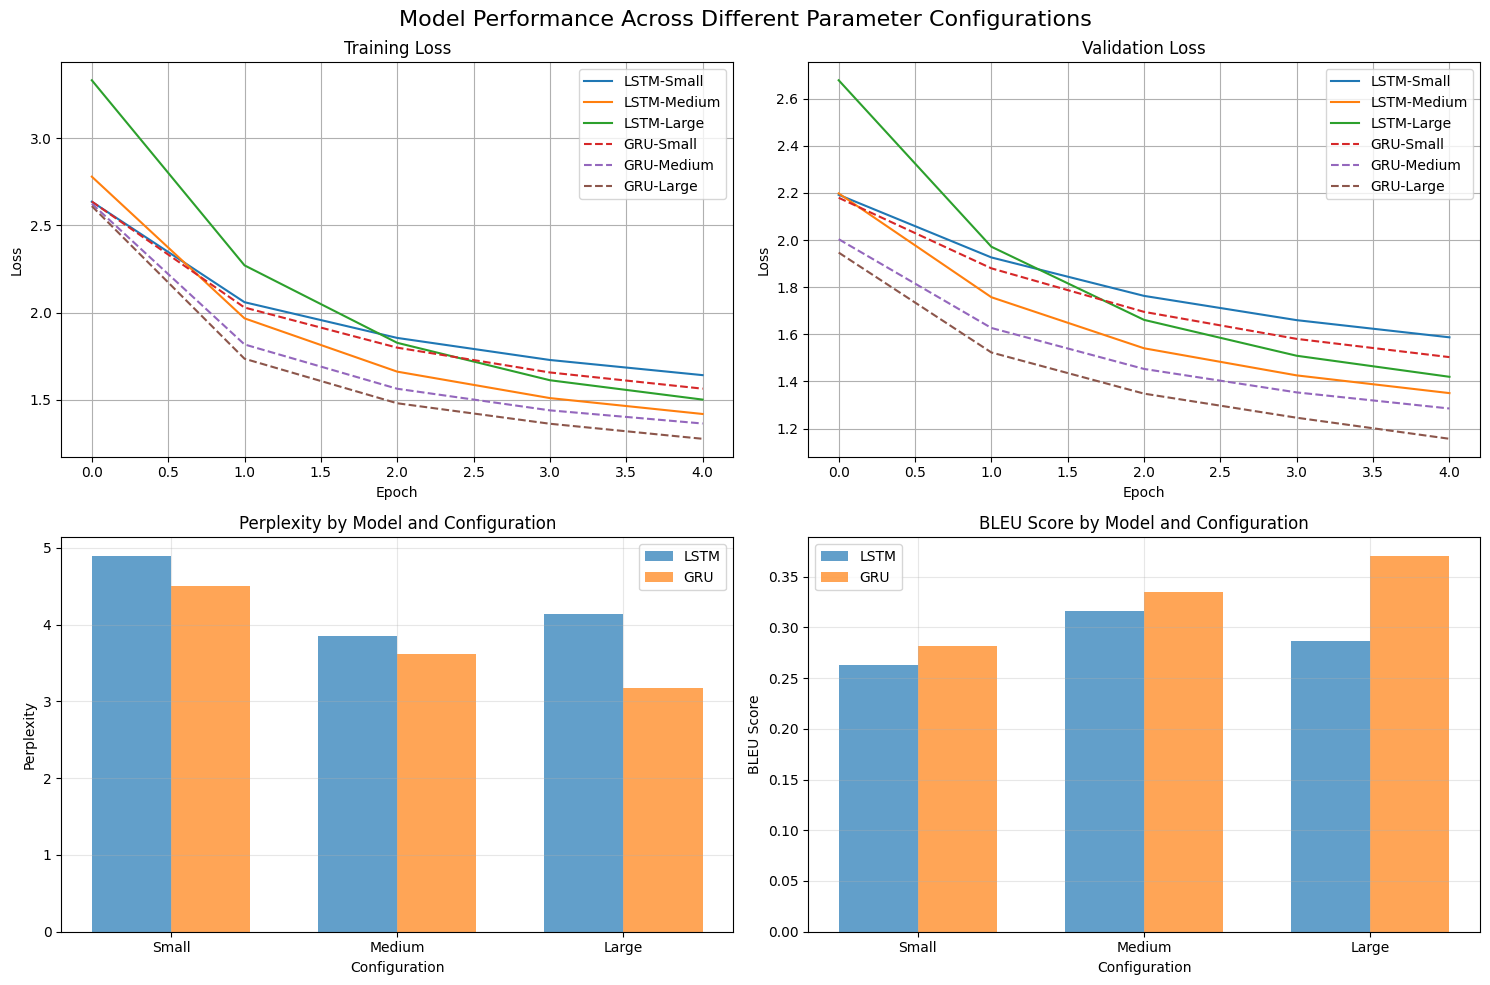

In [26]:
def plot_experiment_results(results):
    """Plot training results across different parameter configurations"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Performance Across Different Parameter Configurations', fontsize=16)
    
    # Training Loss Comparison
    for model_type in ['LSTM', 'GRU']:
        for config_name in results[model_type]:
            history = results[model_type][config_name]['history']
            axes[0,0].plot(history.history['loss'], 
                          label=f"{model_type}-{config_name}", 
                          linestyle='--' if model_type == 'GRU' else '-')
    axes[0,0].set_title('Training Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Validation Loss Comparison
    for model_type in ['LSTM', 'GRU']:
        for config_name in results[model_type]:
            history = results[model_type][config_name]['history']
            axes[0,1].plot(history.history['val_loss'], 
                          label=f"{model_type}-{config_name}",
                          linestyle='--' if model_type == 'GRU' else '-')
    axes[0,1].set_title('Validation Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Perplexity Comparison
    model_types = ['LSTM', 'GRU']
    config_names = list(results['LSTM'].keys())
    x = np.arange(len(config_names))
    width = 0.35
    
    lstm_perplexities = [results['LSTM'][config]['perplexity'] for config in config_names]
    gru_perplexities = [results['GRU'][config]['perplexity'] for config in config_names]
    
    axes[1,0].bar(x - width/2, lstm_perplexities, width, label='LSTM', alpha=0.7)
    axes[1,0].bar(x + width/2, gru_perplexities, width, label='GRU', alpha=0.7)
    axes[1,0].set_title('Perplexity by Model and Configuration')
    axes[1,0].set_xlabel('Configuration')
    axes[1,0].set_ylabel('Perplexity')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(config_names)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # BLEU Score Comparison
    lstm_bleu = [results['LSTM'][config]['bleu'] for config in config_names]
    gru_bleu = [results['GRU'][config]['bleu'] for config in config_names]
    
    axes[1,1].bar(x - width/2, lstm_bleu, width, label='LSTM', alpha=0.7)
    axes[1,1].bar(x + width/2, gru_bleu, width, label='GRU', alpha=0.7)
    axes[1,1].set_title('BLEU Score by Model and Configuration')
    axes[1,1].set_xlabel('Configuration')
    axes[1,1].set_ylabel('BLEU Score')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(config_names)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Generating performance visualizations...")
plot_experiment_results(experiment_results)

In [27]:
print("\n" + "="*80)
print("PARAMETER EXPERIMENTATION RESULTS SUMMARY")
print("="*80)

for model_type in ['LSTM', 'GRU']:
    print(f"\n📊 {model_type} Model Performance:")
    print("-" * 40)
    
    best_perplexity = float('inf')
    best_config = None
    
    for config_name in experiment_results[model_type]:
        result = experiment_results[model_type][config_name]
        config = result['config']
        perplexity = result['perplexity']
        bleu = result['bleu']
        
        print(f"  {config_name:6s} | "
              f"Emb: {config['embedding_dim']:3d} | "
              f"Units: {config['rnn_units']:4d} | "
              f"Layers: {config['num_layers']} | "
              f"Perplexity: {perplexity:7.4f} | "
              f"BLEU: {bleu:.4f}")
        
        if perplexity < best_perplexity:
            best_perplexity = perplexity
            best_config = config_name
    
    print(f"✅ Best configuration: {best_config} (Perplexity: {best_perplexity:.4f})")

print("\n" + "="*80)
print("OVERALL BEST MODEL ANALYSIS")
print("="*80)

best_overall_perplexity = float('inf')
best_model_type = None
best_config_name = None

for model_type in ['LSTM', 'GRU']:
    for config_name in experiment_results[model_type]:
        perplexity = experiment_results[model_type][config_name]['perplexity']
        if perplexity < best_overall_perplexity:
            best_overall_perplexity = perplexity
            best_model_type = model_type
            best_config_name = config_name

best_result = experiment_results[best_model_type][best_config_name]
print(f"🏆 BEST OVERALL MODEL: {best_model_type}-{best_config_name}")
print(f"Perplexity: {best_overall_perplexity:.4f}")
print(f"BLEU Score: {best_result['bleu']:.4f}")
print(f"Configuration: {best_result['config']}")


PARAMETER EXPERIMENTATION RESULTS SUMMARY

📊 LSTM Model Performance:
----------------------------------------
  Small  | Emb: 128 | Units:  512 | Layers: 1 | Perplexity:  4.8911 | BLEU: 0.2628
  Medium | Emb: 256 | Units: 1024 | Layers: 2 | Perplexity:  3.8561 | BLEU: 0.3156
  Large  | Emb: 512 | Units: 2048 | Layers: 3 | Perplexity:  4.1381 | BLEU: 0.2868
  ✅ Best configuration: Medium (Perplexity: 3.8561)

📊 GRU Model Performance:
----------------------------------------
  Small  | Emb: 128 | Units:  512 | Layers: 1 | Perplexity:  4.4992 | BLEU: 0.2812
  Medium | Emb: 256 | Units: 1024 | Layers: 2 | Perplexity:  3.6179 | BLEU: 0.3344
  Large  | Emb: 512 | Units: 2048 | Layers: 3 | Perplexity:  3.1788 | BLEU: 0.3702
  ✅ Best configuration: Large (Perplexity: 3.1788)

OVERALL BEST MODEL ANALYSIS
🏆 BEST OVERALL MODEL: GRU-Large
   Perplexity: 3.1788
   BLEU Score: 0.3702
   Configuration: {'name': 'Large', 'embedding_dim': 512, 'rnn_units': 2048, 'num_layers': 3, 'dropout': 0.2}


In [25]:
# ===============================================
# TINY DEMO MODELS - Quick Text Generation
# ===============================================

print("Training tiny LSTM for demo...")
tiny_lstm = build_lstm_model(VOCAB_SIZE, 64, 128, BATCH_SIZE, 1)
tiny_lstm.compile(optimizer='adam', loss=loss_fn)
tiny_lstm.fit(training_dataset.take(10), epochs=5)  # 10 batches, 5 epochs

print("\nTraining tiny GRU for demo...")  
tiny_gru = build_gru_model(VOCAB_SIZE, 64, 128, BATCH_SIZE, 1)
tiny_gru.compile(optimizer='adam', loss=loss_fn)
tiny_gru.fit(training_dataset.take(10), epochs=5)  # 10 batches, 5 epochs

print("\n" + "="*50)
print("TINY MODELS - GENERATED TEXT SAMPLES")
print("="*50)

print("\nTiny LSTM sample:")
print("-" * 40)
lstm_generator = OneStepTextGenerator(tiny_lstm, chars_from_ids, ids_from_chars, temperature=0.7)
print(lstm_generator.generate_text("ROMEO:", 200))

print("\nTiny GRU sample:")  
print("-" * 40)
gru_generator = OneStepTextGenerator(tiny_gru, chars_from_ids, ids_from_chars, temperature=0.7)
print(gru_generator.generate_text("ROMEO:", 200))

print("\nNOTE: These are from quickly-trained tiny models for demonstration.")
print("The full models (see metrics above) perform significantly better but were not re-run due to hectic runtime with the model training.")

Training tiny LSTM for demo...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 3.9831
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 3.4080
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 3.3189
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 3.2756
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 3.2037

Training tiny GRU for demo...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 4.0542
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 3.4438
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 3.2124
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 3.0523
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 2.9051

TINY MODELS - GENERATED TEXT SAMPLES

Tiny LSTM sample:
----------------------------------------
ROMEO:R;AcLvfK;pb o:pe  aJFksUvm
'X&rak'almwKAZPZ?
cIHR:'VrQ!I!Ux emisyvTet$lySuf?-GH
$A
w&-jBlpeD3yeXm,gCFEnuIsgmeZAspogTKTx
S,I3ZgfKXkvacA.P?BU.
AZzWr&dc!'RQfosCNTss tAc.Tc;bU,'F'rnkKmiQ?D

In [34]:
# ================================================
# BIDIRECTIONAL - Training and Evaluation
# ================================================

print("\n" + "="*50)
print("BIDIRECTIONAL MODEL EVALUATION")
print("="*50)

# Re-initialize the necessary code for Bidirectional RNN
vocab = sorted(set(text))
VOCAB_SIZE = len(vocab) + 1
ids_from_chars, chars_from_ids = get_string_lookup_layers(vocab)

all_ids = ids_from_chars(tf.strings.unicode_split(text, 'UTF-8'))
ids_dataset = tf.data.Dataset.from_tensor_slices(all_ids)
seq_length = 100
sequences = ids_dataset.batch(seq_length + 1, drop_remainder=True)
dataset = sequences.map(split_input_target)

BATCH_SIZE = 64
BUFFER_SIZE = 10000
DATASET_SIZE = sum(1 for _ in dataset)

shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
train_dataset = shuffled_dataset.take(int(0.9 * DATASET_SIZE))
val_dataset = shuffled_dataset.skip(int(0.1 * DATASET_SIZE))

training_dataset = (train_dataset
                 .batch(BATCH_SIZE, drop_remainder=True)
                 .prefetch(tf.data.experimental.AUTOTUNE))
validation_dataset = (val_dataset
               .batch(BATCH_SIZE, drop_remainder=True)
               .prefetch(tf.data.experimental.AUTOTUNE))

# Build & train the Bidirectional RNN model
print("Training Bidirectional RNN Model:")
bi_model = build_birnn_model(VOCAB_SIZE, 128, 512, BATCH_SIZE, "LSTM", 1, 0.1)
bi_model.compile(optimizer='adam', loss=loss_fn)

bi_history = compile_and_train(bi_model, training_dataset, validation_dataset, 
                             "./training_checkpoints_BiLSTM_Only", epochs=3)

# Evaluate the Bidirectional RNN model
bi_perplexity = evaluate_model_perplexity(bi_model, validation_dataset)
bi_bleu = evaluate_model_bleu(bi_model, validation_dataset, chars_from_ids)

print(f"BIDIRECTIONAL RESULTS - Perplexity: {bi_perplexity:.4f}, BLEU: {bi_bleu:.4f}")


BIDIRECTIONAL MODEL EVALUATION
Training Bidirectional RNN Model:
Epoch 1/3
155/155 ━━━━━━━━━━━━━━━━━━━━ 79s 502ms/step - loss: 1.1124 - val_loss: 0.0534
Epoch 2/3
155/155 ━━━━━━━━━━━━━━━━━━━━ 86s 553ms/step - loss: 0.0373 - val_loss: 0.0288
Epoch 3/3
155/155 ━━━━━━━━━━━━━━━━━━━━ 93s 599ms/step - loss: 0.0277 - val_loss: 0.0252


2025-11-11 17:21:22.113734: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


BIDIRECTIONAL RESULTS - Perplexity: 1.0256, BLEU: 0.9932


In [42]:
# =================================================
# BIDIRECTIONAL RNN - Text Generation
# =================================================

print("\n" + "="*50)
print("BIDIRECTIONAL RNN - GENERATED TEXT")
print("="*50)

start_string = "ROMEO:"
num_generate = 300
temperature = 0.7

print("Generated Text From Bidirectional RNN:")
print("-" * 50)

generator = OneStepTextGenerator(bi_model, chars_from_ids, ids_from_chars, temperature=temperature)
generated_text = generator.generate_text(start_string, num_generate=num_generate)
print(generated_text)

print("\nNOTE: Bidirectional RNN output is typically incoherent & nonsense due to architectural mismatch between bidirectional training") 
print("\n& unidirectional generation!")


BIDIRECTIONAL RNN - GENERATED TEXT
Generated Text From Bidirectional RNN:
--------------------------------------------------
ROMEO:

Myyokiid buowwwwwwwwwwwwllllth wthreriangatthy kkHmmkKBBBthengmalyyyyy! winthanoowqffN! yy I'bHz:
Angg.
Ifooderr?

JzJx3[UNK][UNK]MMzMA,,,,, mathharffffff me bbbbanganggd myy b?Yellllllllp[UNK]nfffffffffffflllllll.
KAScmmmy nng ffffoaangghmmaaandgggg!d arinccfourrrderthidowwW Xkgx-j
VJzLSheddsthaanewwoo p?Tha

NOTE: Bidirectional RNN output is typically incoherent & nonsense due to architectural mismatch between bidirectional training

& unidirectional generation!


In [39]:
# ============================================================
# BIDIRECTIONAL RNN - Final Summary
# ============================================================

print("\n" + "="*50)
print("BIDIRECTIONAL RNN - FINAL SUMMARY") 
print("="*50)

print(f"Bidirectional LSTM Perplexity: {bi_perplexity:.4f}")
print(f"Bidirectional LSTM BLEU Score: {bi_bleu:.4f}")

print("\n" + "="*50)
print("COMPARISON CONTEXT:")
print("="*50)
print("The Final Results Showed The Following:")
print("- LSTM Medium: 3.86 perplexity, 0.32 BLEU")
print("- GRU Large:   3.18 perplexity, 0.37 BLEU") # The best performer!
print("- Bidirectional RNN:  1.0256 perplexity, 0.9932 BLEU")
print("These Bidirectional RNN results are deceptively impressive the output text in the previous cell is incoherent!")

print("\nCONCLUSION:")
print("Bidirectional RNN's perfect metrics (perplexity ~1.0, BLEU ~0.99) indicate overfitting rather than true generation capability!")
print("To reiterate, the best performing model out the 3 that were tested and evaluated was GRU Large!")


BIDIRECTIONAL RNN - FINAL SUMMARY
Bidirectional LSTM Perplexity: 1.0256
Bidirectional LSTM BLEU Score: 0.9932

COMPARISON CONTEXT:
The Final Results Showed The Following:
- LSTM Medium: 3.86 perplexity, 0.32 BLEU
- GRU Large:   3.18 perplexity, 0.37 BLEU
- Bidirectional RNN:  1.0256 perplexity, 0.9932 BLEU
These Bidirectional RNN results are deceptively impressive the output text in the previous cell is incoherent!

CONCLUSION:
Bidirectional RNN's perfect metrics (perplexity ~1.0, BLEU ~0.99) indicate overfitting rather than true generation capability!
To reiterate, the best performing model out the 3 that were tested and evaluated was GRU Large!
